In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
# Data cleaning: Convert percentage strings to float
def clean_percentage(x):
    if isinstance(x, str):
        # Remove '%' and '+', and then convert to decimal.
        return float(x.replace('%', '').replace('+', '')) / 100.0
    return x

def clean_currency(val):
    if pd.isna(val) or val == '--': 
        return np.nan
    # Remove $, commas, and spaces
    currency = ''
    if '$' in val:
        currency = '$'
    elif '￥' in val:
        currency = '￥'
    elif '€' in val:
        currency = '€'
    elif '￡' in val:
        currency = '￡'
    clean_val = str(val).replace(currency, '').strip()
    try:
        return float(clean_val)
    except ValueError:
        return np.nan

In [3]:
# 1. load data
file_path = r"data/twitter_yoy_growth.csv"
df = pd.read_csv(file_path)

# 2. Data cleaning: Convert percentage strings to float
df['multimedia_ratio_num'] = df['multimedia_ratio'].apply(clean_percentage)
df['total_yoy_growth_num'] = df['total_yoy_growth'].apply(clean_percentage)
df['stock_open_price_num'] = df['stock_open_price'].apply(clean_currency)
df['stock_close_price_num'] = df['stock_close_price'].apply(clean_currency)

df['stock_growth'] = (df['stock_close_price_num'] - df['stock_open_price_num']) / df['stock_open_price_num']

# 3. Correlation analysis
cols_of_interest = [
    'num_tweet', 'engagement_rate', 
    'multimedia_ratio_num', 'total_yoy_growth_num', 'stock_growth'
]
corr_matrix = df[cols_of_interest].corr()
print("--- Correlation Matrix ---")
print(corr_matrix)

# 4. Ordinary Least Squares (OLS)
analysis_data = df[cols_of_interest].dropna()
X = analysis_data[['num_tweet', 'engagement_rate', 'multimedia_ratio_num']]
X = sm.add_constant(X)
y = analysis_data['stock_growth']

model = sm.OLS(y, X).fit()
print("\n--- Summary of Regression Model ---")
print(model.summary())

--- Correlation Matrix ---
                      num_tweet  engagement_rate  multimedia_ratio_num  \
num_tweet              1.000000        -0.167206             -0.234222   
engagement_rate       -0.167206         1.000000              0.098592   
multimedia_ratio_num  -0.234222         0.098592              1.000000   
total_yoy_growth_num   0.241668         0.021863              0.030039   
stock_growth           0.123194        -0.043151             -0.044456   

                      total_yoy_growth_num  stock_growth  
num_tweet                         0.241668      0.123194  
engagement_rate                   0.021863     -0.043151  
multimedia_ratio_num              0.030039     -0.044456  
total_yoy_growth_num              1.000000      0.350869  
stock_growth                      0.350869      1.000000  

--- Summary of Regression Model ---
                            OLS Regression Results                            
Dep. Variable:           stock_growth   R-squared:        

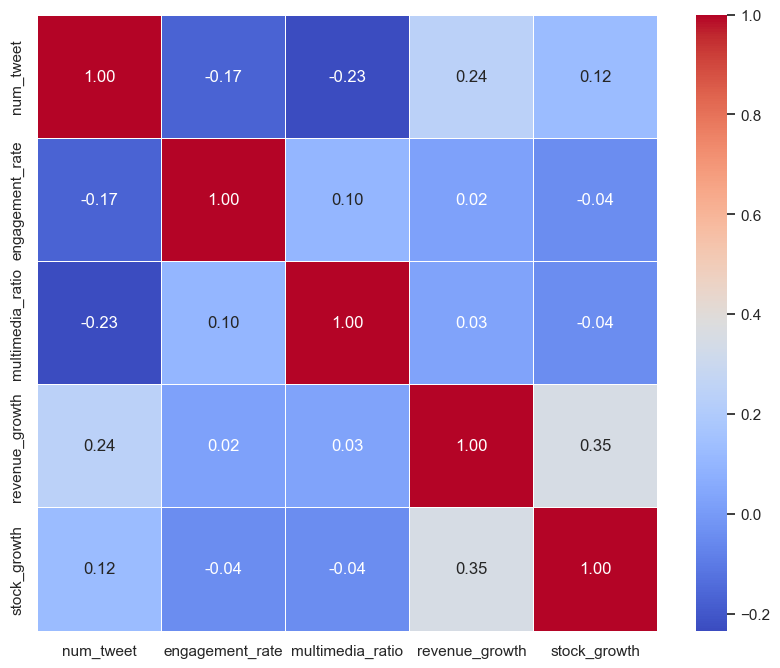

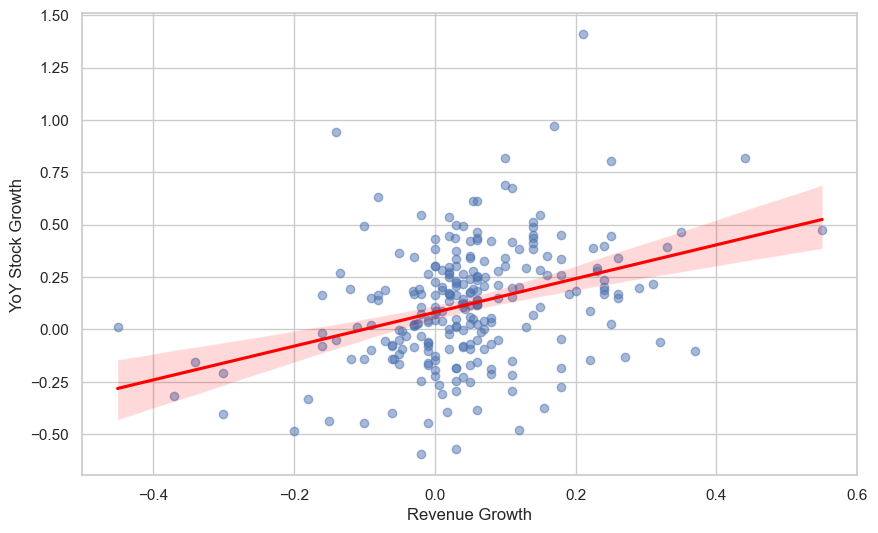

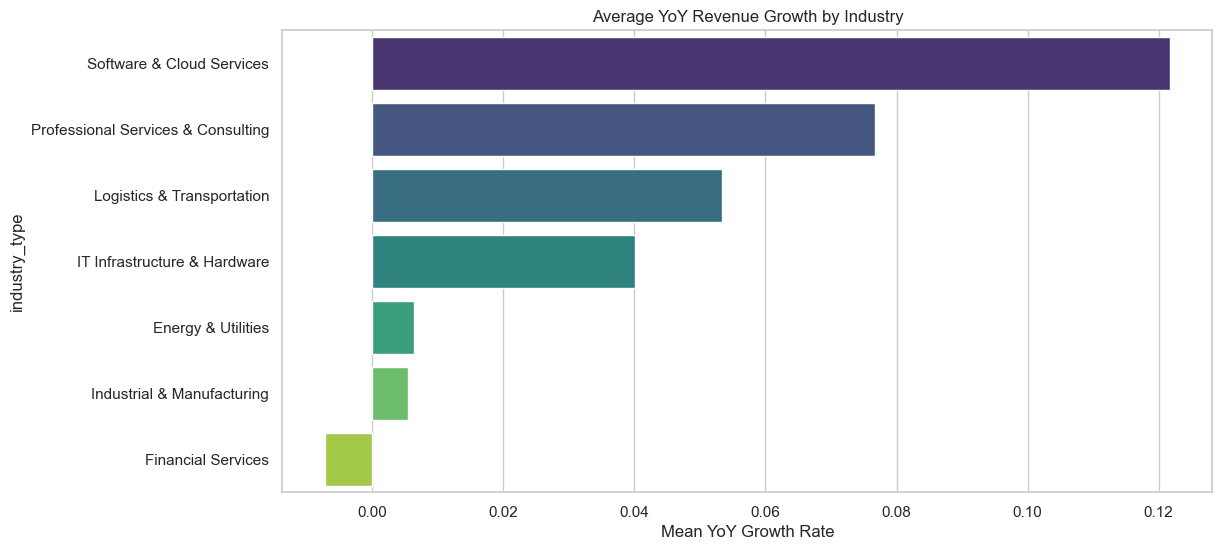

In [4]:
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Load data and processing
df_raw = pd.read_csv(file_path)

df = df_raw.copy()
df['multimedia_ratio'] = df_raw['multimedia_ratio'].apply(clean_percentage)
df['revenue_growth'] = df_raw['total_yoy_growth'].apply(clean_percentage)
df['stock_open_price_num'] = df_raw['stock_open_price'].apply(clean_currency)
df['stock_close_price_num'] = df_raw['stock_close_price'].apply(clean_currency)

df['stock_growth'] = (df['stock_close_price_num'] - df['stock_open_price_num']) / df['stock_open_price_num']


# 2. Correlation heatmap
plt.figure(figsize=(10, 8))
cols_of_interest = ['num_tweet', 'engagement_rate', 'multimedia_ratio', 'revenue_growth', 'stock_growth']
corr_matrix = df[cols_of_interest].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
#plt.title('Correlation Heatmap: Twitter Metrics vs. Revenue Growth')
plt.savefig('correlation_heatmap.png', dpi=1000)

# 3. Significant variable regression chart: Number of tweets vs. Revenue growth
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='revenue_growth', y='stock_growth', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
#plt.title('Significant Relationship: Revenue Growth vs. Stock Growth')
plt.xlabel('Revenue Growth')
plt.ylabel('YoY Stock Growth')
plt.savefig('revenue_growth_vs_stock_growth.png', dpi=1000)

# 4. Average growth rate bar chart for various industries
plt.figure(figsize=(12, 6))
industry_growth = df.groupby('industry_type')['revenue_growth'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=industry_growth, x='revenue_growth', y='industry_type', palette='viridis')
plt.title('Average YoY Revenue Growth by Industry')
plt.xlabel('Mean YoY Growth Rate')
plt.savefig('growth_by_industry.png', dpi=1000)

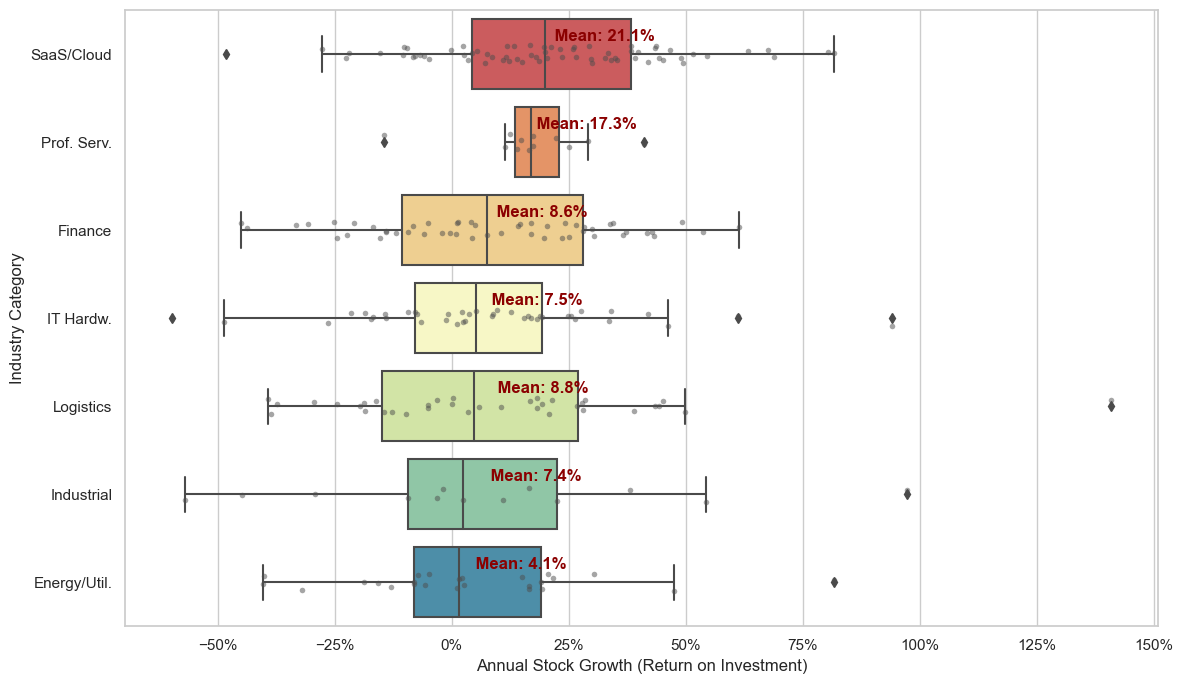

In [5]:
from matplotlib.ticker import PercentFormatter

# Abbreviation: Mapping Processing
industry_map = {
    'Professional Services & Consulting': 'Prof. Serv.',
    'IT Infrastructure & Hardware': 'IT Hardw.',
    'Software & Cloud Services': 'SaaS/Cloud',
    'Logistics & Transportation': 'Logistics',
    'Industrial & Manufacturing': 'Industrial',
    'Energy & Utilities': 'Energy/Util.',
    'Financial Services': 'Finance'
}
df['industry_abbr'] = df['industry_type'].map(industry_map)

full_order = df.groupby('industry_type')['stock_growth'].median().sort_values(ascending=False).index
abbr_order = [industry_map[name] for name in full_order]

# Plot
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(data=df, x='stock_growth', y='industry_abbr', order=abbr_order, palette='Spectral')
sns.stripplot(data=df, x='stock_growth', y='industry_abbr', order=abbr_order, color=".3", size=4, alpha=0.5)

means = df.groupby('industry_abbr')['stock_growth'].mean().reindex(abbr_order)
for i, mean_val in enumerate(means):
    if not np.isnan(mean_val):
        ax.text(mean_val, i-0.2, f' Mean: {mean_val:.1%}', color='darkred', va='center', fontweight='bold')

#plt.title('Stock Growth Distribution by Industry', fontsize=15)
plt.xlabel('Annual Stock Growth (Return on Investment)')
plt.ylabel('Industry Category')

# Set the X-axis to be in percentage format
ax.xaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.savefig('industry_stock_growth.png', dpi=1000)